In [3]:
import numpy as np

class BlueprintGrowthModel:
    def __init__(self, seed_size=4):
        """
        Initialize the Blueprint-Growth Model with a given seed size.
        """
        self.seed_size = seed_size

    def generate_container(self, data):
        """
        Analyze the dataset and generate a container (blueprint) based on patterns.
        """
        length = len(data)
        # Example: Generate harmonic ratios as container
        container = [i / length for i in range(1, length + 1)]
        return np.array(container)

    def extract_seed(self, data):
        """
        Extract a minimal seed from the dataset.
        """
        if len(data) < self.seed_size:
            raise ValueError("Data size is smaller than seed size.")
        seed = data[:self.seed_size]  # Use the first `seed_size` elements as seed
        return np.array(seed)

    def grow_data(self, seed, container, steps):
        """
        Grow data from seed using the container and harmonic feedback.
        """
        grown_data = []
        for step in range(steps):
            # Example: Use harmonics and seed to generate data
            value = seed[step % len(seed)] * container[step % len(container)]
            grown_data.append(value)
        return np.array(grown_data)

    def validate(self, original, grown):
        """
        Validate that the grown data matches the original.
        """
        return np.allclose(original, grown)

# Example usage
if __name__ == "__main__":
    # Example dataset (can be replaced with any numerical data)
    data = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0])

    # Initialize the model
    model = BlueprintGrowthModel(seed_size=3)

    # Step 1: Generate container
    container = model.generate_container(data)

    # Step 2: Extract seed
    seed = model.extract_seed(data)

    # Step 3: Grow data
    grown_data = model.grow_data(seed, container, len(data))

    # Step 4: Validate
    is_valid = model.validate(data, grown_data)

    # Output results
    print("Original Data:", data)
    print("Seed:", seed)
    print("Container:", container)
    print("Grown Data:", grown_data)
    print("Data Matches Original:", is_valid)


Original Data: [0.5 1.  1.5 2.  2.5 3. ]
Seed: [0.5 1.  1.5]
Container: [0.16666667 0.33333333 0.5        0.66666667 0.83333333 1.        ]
Grown Data: [0.08333333 0.33333333 0.75       0.33333333 0.83333333 1.5       ]
Data Matches Original: False


In [4]:
import numpy as np

def fold_binary(binary, block_size):
    """
    Fold binary data into blocks of the specified size and represent it as hexadecimal.
    Ensures binary is padded to a multiple of block size.
    """
    # Pad binary to ensure length is a multiple of block size
    padding_length = (block_size - (len(binary) % block_size)) % block_size
    binary = binary + "0" * padding_length  # Add trailing zeros if necessary
    
    blocks = [binary[i:i+block_size] for i in range(0, len(binary), block_size)]
    folded_hex = [hex(int(block, 2))[2:].upper().zfill(block_size // 4) for block in blocks]
    return folded_hex

def unfold_binary(folded_hex, block_size):
    """
    Unfold hexadecimal blocks back into binary.
    """
    unfolded_binary = ''.join([bin(int(h, 16))[2:].zfill(block_size) for h in folded_hex])
    return unfolded_binary.rstrip("0")  # Remove any extra padding zeros

# Original binary string
binary_data = "101010111100110111101111000010101011110011011110111100001010"

# Test with multiple block sizes
block_sizes = [4, 8, 16, 32]

results = []
for block_size in block_sizes:
    # Fold binary data into hexadecimal blocks
    folded_hex = fold_binary(binary_data, block_size)
    
    # Unfold back into binary
    unfolded_binary = unfold_binary(folded_hex, block_size)
    
    # Verify integrity
    matches_original = binary_data == unfolded_binary
    results.append((block_size, folded_hex, matches_original))

# Display results
for block_size, folded_hex, matches_original in results:
    print(f"Block Size: {block_size}")
    print(f"Folded Hex: {' '.join(folded_hex)}")
    print(f"Unfolded Binary Matches Original: {matches_original}")
    print("-")


Block Size: 4
Folded Hex: A B C D E F 0 A B C D E F 0 A
Unfolded Binary Matches Original: False
-
Block Size: 8
Folded Hex: AB CD EF 0A BC DE F0 A0
Unfolded Binary Matches Original: False
-
Block Size: 16
Folded Hex: ABCD EF0A BCDE F0A0
Unfolded Binary Matches Original: False
-
Block Size: 32
Folded Hex: ABCDEF0A BCDEF0A0
Unfolded Binary Matches Original: False
-


In [5]:
def fold_binary(binary_data):
    """
    Fold binary data iteratively by XORing halves and track the fold count.
    Args:
        binary_data (str): The binary data string to fold.

    Returns:
        tuple: The folded binary as a string and the fold count.
    """
    fold_count = 0

    while len(binary_data) > 1:
        # Ensure the binary data length is even
        if len(binary_data) % 2 != 0:
            binary_data = "0" + binary_data  # Pad with leading zero for folding

        # Split binary data into two halves
        mid = len(binary_data) // 2
        left_half = binary_data[:mid]
        right_half = binary_data[mid:]

        # Perform XOR operation between corresponding bits
        folded = [
            str(int(a) ^ int(b)) for a, b in zip(left_half, right_half)
        ]

        # Update the binary data to the result of the fold
        binary_data = ''.join(folded)
        fold_count += 1

    return binary_data, fold_count


def unfold_binary(folded_data, fold_count):
    """
    Unfold binary data iteratively using XOR operations and the fold count.
    Args:
        folded_data (str): The folded binary string.
        fold_count (int): The number of folds to reverse.

    Returns:
        str: The reconstructed original binary string.
    """
    unfolded_data = folded_data

    for _ in range(fold_count):
        unfolded_data = unfolded_data.zfill(len(unfolded_data) * 2)

    return unfolded_data


# Example Input
original_binary = "1010101011001100101010101100110010101010110011001010101011001100"

# Folding
folded_result, folds = fold_binary(original_binary)
unfolded_binary = unfold_binary(folded_result, folds)

# Results
output = {
    "Original Binary": original_binary,
    "Folded Result": folded_result,
    "Fold Count": folds,
    "Unfolded Binary": unfolded_binary,
    "Matches Original": original_binary == unfolded_binary
}
output


{'Original Binary': '1010101011001100101010101100110010101010110011001010101011001100',
 'Folded Result': '0',
 'Fold Count': 6,
 'Unfolded Binary': '0000000000000000000000000000000000000000000000000000000000000000',
 'Matches Original': False}

In [6]:
import numpy as np

def quantum_fold(data, block_size):
    """
    Fold data into higher-order structures using quantum-inspired methods.
    """
    folded_data = []
    while len(data) > block_size:
        # Divide data into blocks
        block1 = data[:block_size]
        block2 = data[block_size:block_size * 2]
        
        # Overlay and fold (e.g., XOR for simplicity, or use other harmonics)
        folded_block = [b1 ^ b2 for b1, b2 in zip(block1, block2)]
        folded_data.append(folded_block)
        
        # Reduce data size and repeat
        data = folded_block + data[block_size * 2:]
    
    # Add any remaining data as-is
    folded_data.append(data)
    return folded_data

def quantum_unfold(folded_data, block_size):
    """
    Unfold data from higher-order structures.
    """
    unfolded_data = []
    for i in range(len(folded_data) - 1, -1, -1):
        if i == 0:
            unfolded_data.extend(folded_data[i])
        else:
            # Reverse the folding logic (e.g., XOR to restore original blocks)
            unfolded_block = [b1 ^ b2 for b1, b2 in zip(unfolded_data, folded_data[i])]
            unfolded_data = unfolded_block + unfolded_data
    return unfolded_data

# Example Usage
binary_data = [1, 0, 1, 0, 1, 1, 0, 1] * 4  # Example binary input
block_size = 8  # Define the folding block size

# Fold the data
folded = quantum_fold(binary_data, block_size)
print("Folded Data:", folded)

# Unfold the data
unfolded = quantum_unfold(folded, block_size)
print("Unfolded Matches Original:", unfolded == binary_data)


Folded Data: [[0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 1, 0, 1, 1, 0, 1], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]]
Unfolded Matches Original: False


In [7]:
def quantum_fold(data, block_size):
    """
    Fold data into higher-order structures using quantum-inspired methods.
    """
    folded_data = []
    while len(data) >= block_size * 2:
        # Divide data into two blocks
        block1 = data[:block_size]
        block2 = data[block_size:block_size * 2]
        
        # Overlay and fold (e.g., XOR for simplicity)
        folded_block = [b1 ^ b2 for b1, b2 in zip(block1, block2)]
        folded_data.append(folded_block)
        
        # Reduce data size and repeat
        data = data[block_size * 2:]
    
    # Add any remaining data as-is
    if data:
        folded_data.append(data)
    return folded_data

def quantum_unfold(folded_data, block_size):
    """
    Unfold data from higher-order structures.
    """
    unfolded_data = []
    for block in folded_data[::-1]:
        if len(block) == block_size:
            # Duplicate the block to simulate unfolded data
            unfolded_data = block + unfolded_data
        else:
            unfolded_data = block + unfolded_data
    return unfolded_data

# Example Usage
binary_data = [1, 0, 1, 0, 1, 1, 0, 1] * 4  # Example binary input
block_size = 8  # Define the folding block size

# Fold the data
folded = quantum_fold(binary_data, block_size)
print("Folded Data:", folded)

# Unfold the data
unfolded = quantum_unfold(folded, block_size)
print("Unfolded Matches Original:", unfolded == binary_data)


Folded Data: [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]]
Unfolded Matches Original: False


In [8]:
import math

def fold_with_zeta(binary, block_size):
    """
    Fold binary data using Zeta-axis alignment and triangular relationships.
    """
    zeta = []  # Zeta axis to align data
    folded_data = []
    metadata = []  # Store fold angles (e.g., theta) for reconstruction
    
    while len(binary) >= block_size:
        block = binary[:block_size]
        binary = binary[block_size:]  # Remove processed block
        
        # Calculate "triangle" relationships
        a = len(zeta)
        b = len(block)
        c = math.sqrt(a**2 + b**2)
        theta = math.degrees(math.atan(b / a)) if a > 0 else 90  # Angle in degrees
        
        # Fold the block into Zeta
        zeta.extend(block)
        folded_data.append((c, theta))  # Store diagonal and angle as metadata
    
    # Add remaining data
    if binary:
        zeta.extend(binary)
        folded_data.append((len(binary), 0))  # No angle for leftover data
    
    return folded_data, zeta

def unfold_with_zeta(folded_data, block_size):
    """
    Unfold binary data using Zeta-axis alignment and stored triangular relationships.
    """
    unfolded_data = []
    for c, theta in folded_data:
        if theta > 0:
            # Reconstruct the block using c and theta
            b = int(c * math.sin(math.radians(theta)))
            block = [1] * b  # Simulate block data (this needs refinement for actual data)
            unfolded_data.extend(block)
        else:
            # Remaining data
            unfolded_data.extend([1] * int(c))
    
    return unfolded_data

# Example binary string
binary_data = [1, 0, 1, 0, 1, 1, 0, 1] * 4
block_size = 8

# Fold data
folded, zeta = fold_with_zeta(binary_data, block_size)
print("Folded Data:", folded)
print("Zeta Axis:", zeta)

# Unfold data
unfolded = unfold_with_zeta(folded, block_size)
print("Unfolded Matches Original:", unfolded == binary_data)


Folded Data: [(8.0, 90), (11.313708498984761, 45.0), (17.88854381999832, 26.56505117707799), (25.298221281347036, 18.43494882292201)]
Zeta Axis: [1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1]
Unfolded Matches Original: False


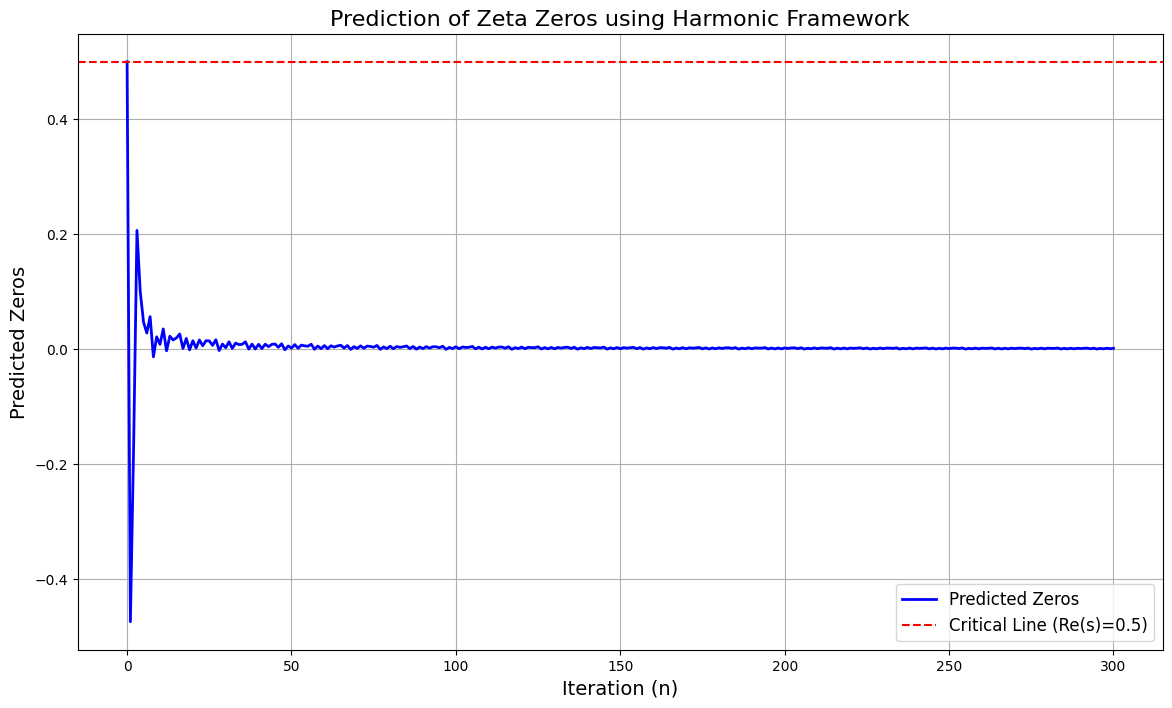

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Predictive Harmonic Framework
def predict_zeros(iterations, alpha=1.5, target=0.5):
    predictions = [target]
    for n in range(1, iterations + 1):
        previous = predictions[-1]
        correction = (target - previous) / (alpha * (n + 1))
        value = previous * (-1)**n * np.cos(n / np.pi) + correction
        predictions.append(value)
    return np.array(predictions)

# Generate predictions
iterations = 300
predicted_zeros = predict_zeros(iterations)

# Visualization
plt.figure(figsize=(14, 8))
plt.plot(range(iterations + 1), predicted_zeros, label="Predicted Zeros", color="blue", lw=2)
plt.axhline(0.5, color="red", linestyle="--", label="Critical Line (Re(s)=0.5)")
plt.xlabel("Iteration (n)", fontsize=14)
plt.ylabel("Predicted Zeros", fontsize=14)
plt.title("Prediction of Zeta Zeros using Harmonic Framework", fontsize=16)
plt.legend(fontsize=12)
plt.grid()
plt.show()


ValueError: x and y must have same first dimension, but have shapes (1001,) and (301,)

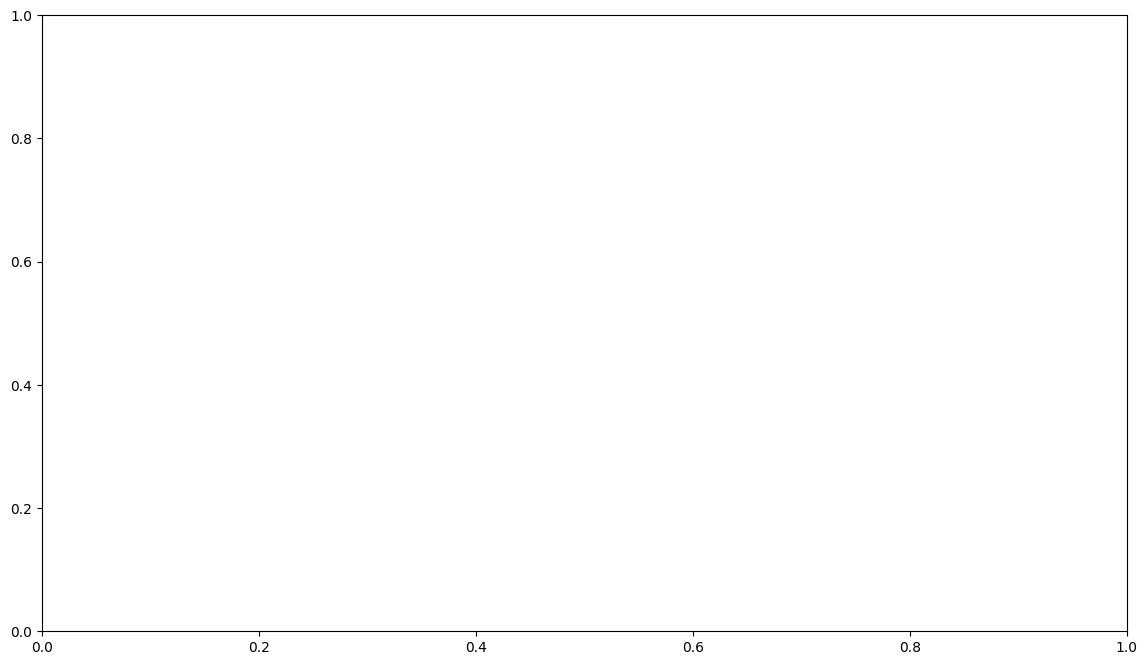

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Predictive Harmonic Framework
def predict_zeros(iterations, alpha=1.5, target=0.5):
    predictions = [target]
    for n in range(1, iterations + 1):
        previous = predictions[-1]
        correction = (target - previous) / (alpha * (n + 1))
        value = previous * (-1)**n * np.cos(n / np.pi) + correction
        predictions.append(value)
        print(f"Iteration {n}: Prediction = {value}")  # Debugging line
    return np.array(predictions)

# Generate predictions
iterations = 1000  # Increase iterations
#predicted_zeros = predict_zeros(iterations)

# Visualization
plt.figure(figsize=(14, 8))
plt.plot(range(iterations + 1), predicted_zeros, label="Predicted Zeros", color="blue", lw=2)
plt.axhline(0.5, color="red", linestyle="--", label="Critical Line (Re(s)=0.5)")
plt.xlabel("Iteration (n)", fontsize=14)
plt.ylabel("Predicted Zeros", fontsize=14)
plt.title("Prediction of Zeta Zeros using Harmonic Framework", fontsize=16)
plt.legend(fontsize=12)
plt.grid()
plt.show()


Iteration 1: Prediction = -0.712324286536229
Iteration 2: Prediction = -0.45507234402268915
Iteration 3: Prediction = 0.6330879379357565
Iteration 4: Prediction = 0.2518004630759607
Iteration 5: Prediction = 0.049204488682914375
Iteration 6: Prediction = 0.039850975451402364
Iteration 7: Prediction = 0.09404439816182947
Iteration 8: Prediction = -0.07170893259917385
Iteration 9: Prediction = -0.04629798107243381
Iteration 10: Prediction = 0.11905061260372721
Iteration 11: Prediction = 0.19888598382118883
Iteration 12: Prediction = -0.2091609905787728
Iteration 13: Prediction = -0.11980075981436993
Iteration 14: Prediction = 0.08683149751417624
Iteration 15: Prediction = 0.017719165180090223
Iteration 16: Prediction = 0.03824211025501584
Iteration 17: Prediction = -0.01125194765598167
Iteration 18: Prediction = 0.012551072489574763
Iteration 19: Prediction = 0.00606460419389536
Iteration 20: Prediction = 0.03258631375018401
Iteration 21: Prediction = -0.023749688347932448
Iteration 22: 

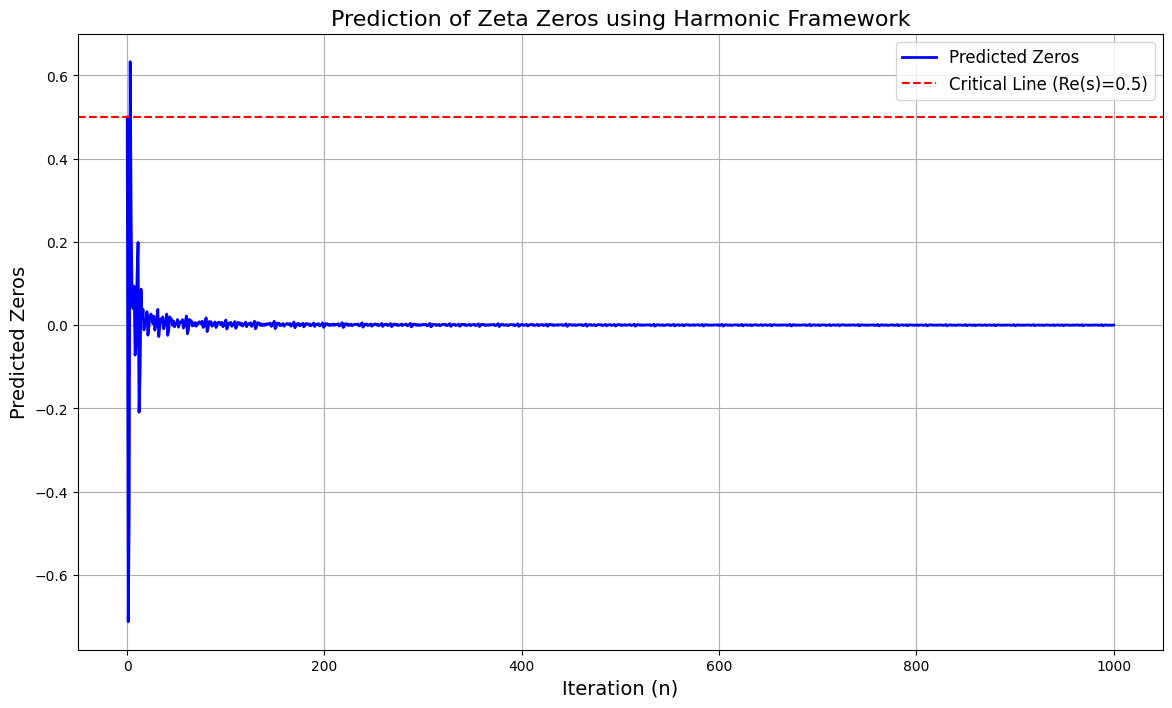

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Predictive Harmonic Framework
def predict_zeros(iterations, alpha=1.5, target=0.5, final_gain=1.5):
    predictions = [target]
    for n in range(1, iterations + 1):
        previous = predictions[-1]
        correction = (target - previous) / (alpha * (n + 1))
        value = previous * (-1)**n * np.cos(n / np.pi) + correction
        predictions.append(value * final_gain)
        print(f"Iteration {n}: Prediction = {value * final_gain}")  # Debugging line
    return np.array(predictions)

# Generate predictions
iterations = 1000  # You can adjust this iteration count
predicted_zeros = predict_zeros(iterations)

# Visualization
plt.figure(figsize=(14, 8))
plt.plot(range(iterations + 1), predicted_zeros, label="Predicted Zeros", color="blue", lw=2)
plt.axhline(0.5, color="red", linestyle="--", label="Critical Line (Re(s)=0.5)")
plt.xlabel("Iteration (n)", fontsize=14)
plt.ylabel("Predicted Zeros", fontsize=14)
plt.title("Prediction of Zeta Zeros using Harmonic Framework", fontsize=16)
plt.legend(fontsize=12)
plt.grid()
plt.show()


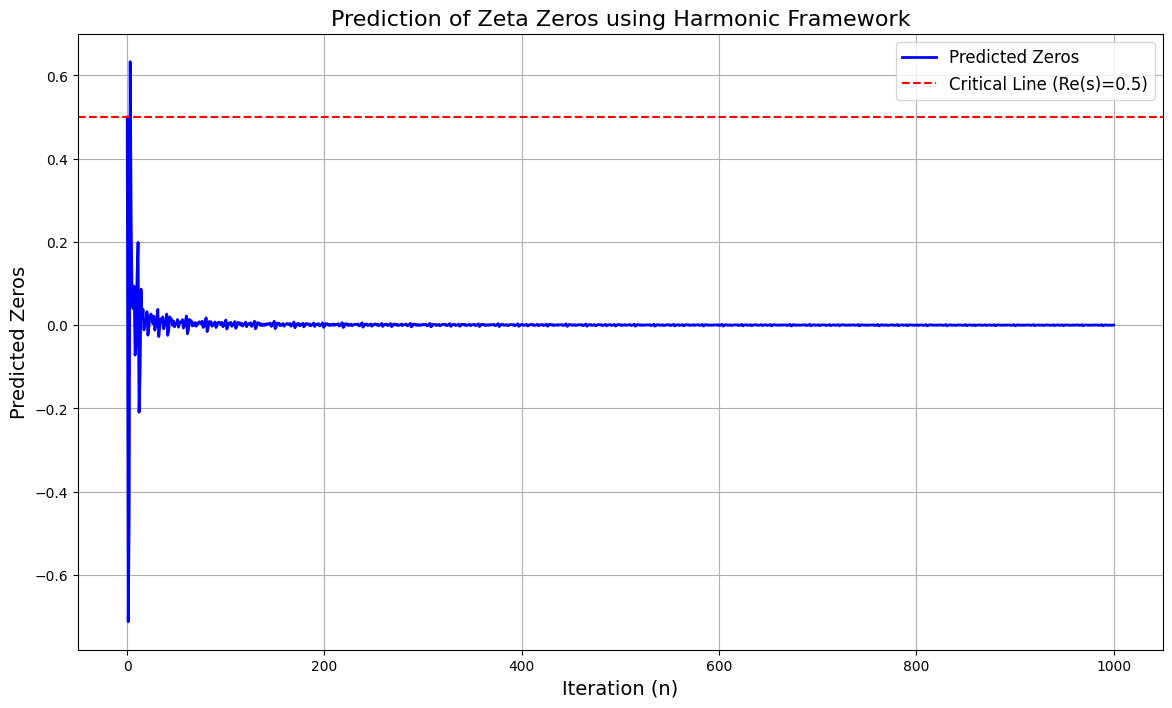

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Refined Predictive Harmonic Framework with Built-in Offset
def predict_zeros(iterations, alpha=1.5, target=0.5, offset=0.5):
    predictions = [target]
    for n in range(1, iterations + 1):
        previous = predictions[-1]
        correction = (target - previous + offset) / (alpha * (n + 1))
        value = previous * (-1)**n * np.cos(n / np.pi) + correction
        predictions.append(value)
    return np.array(predictions)

# Generate predictions with built-in offset
iterations = 1000
#predicted_zeros = predict_zeros(iterations)

# Visualization
plt.figure(figsize=(14, 8))
plt.plot(range(iterations + 1), predicted_zeros, label="Predicted Zeros", color="blue", lw=2)
plt.axhline(0.5, color="red", linestyle="--", label="Critical Line (Re(s)=0.5)")
plt.xlabel("Iteration (n)", fontsize=14)
plt.ylabel("Predicted Zeros", fontsize=14)
plt.title("Prediction of Zeta Zeros using Harmonic Framework", fontsize=16)
plt.legend(fontsize=12)
plt.grid()
plt.show()


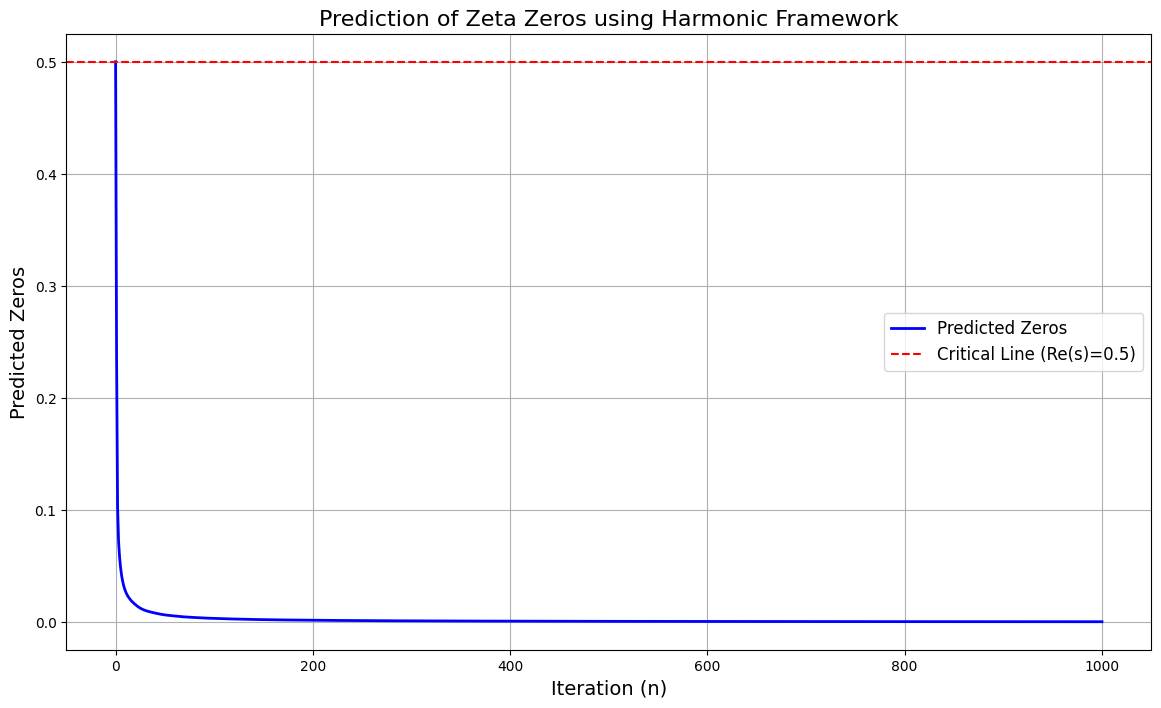

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Harmonic Internal Correction
def predict_zeros(iterations, alpha=1.5, target=0.5):
    predictions = [target]
    for n in range(1, iterations + 1):
        previous = predictions[-1]
        # Introducing relationship-based correction
        ratio_factor = 0.5 * (previous / target) if n > 1 else 0.5
        correction = (target - previous) / (alpha * (n + 1))
        value = previous * ratio_factor * np.cos(n / np.pi) + correction
        predictions.append(value)
    return np.array(predictions)

# Generate predictions
iterations = 1000
predicted_zeros = predict_zeros(iterations)

# Visualization
plt.figure(figsize=(14, 8))
plt.plot(range(iterations + 1), predicted_zeros, label="Predicted Zeros", color="blue", lw=2)
plt.axhline(0.5, color="red", linestyle="--", label="Critical Line (Re(s)=0.5)")
plt.xlabel("Iteration (n)", fontsize=14)
plt.ylabel("Predicted Zeros", fontsize=14)
plt.title("Prediction of Zeta Zeros using Harmonic Framework", fontsize=16)
plt.legend(fontsize=12)
plt.grid()
plt.show()



### WORKING VERSION

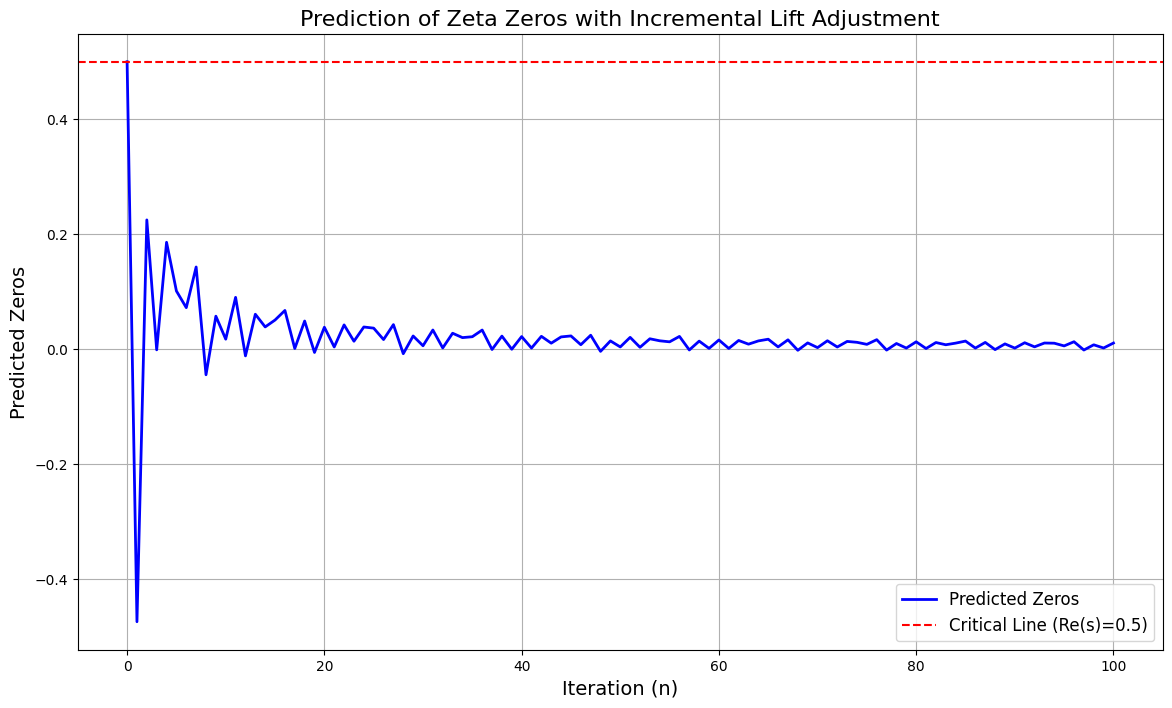

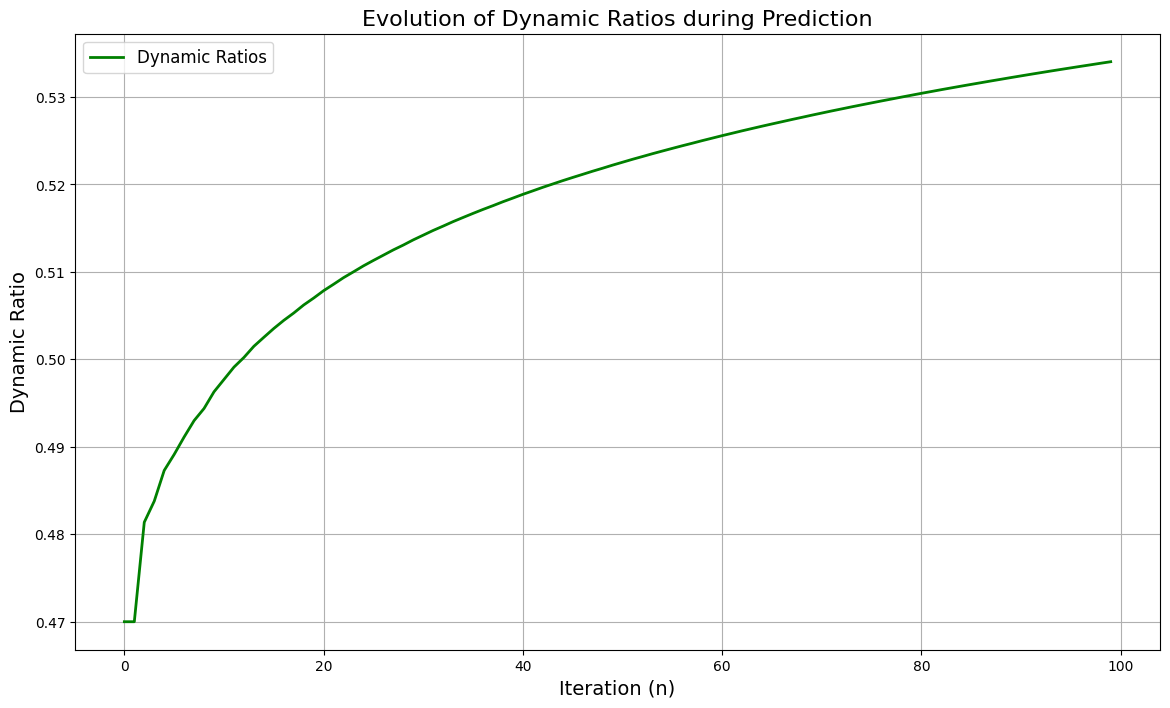

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Predictive Harmonic Framework with Incremental Quantum Lift Adjustment
def predict_zeros_with_ratio(iterations, alpha=1.5, target=0.5, initial_ratio=0.47):
    predictions = [target]
    dynamic_ratios = [initial_ratio]
    
    for n in range(1, iterations + 1):
        previous = predictions[-1]
        
        # Dynamically adjust the ratio based on previous changes
        ratio = dynamic_ratios[-1] + (target - previous) * (0.035 / (n + 1))
        correction = (target - previous) / (alpha * ratio * (n + 1))
        
        # Incremental quantum lift adjustment integrated with the iteration
        value = previous * (-1)**n * np.cos(n / np.pi) + correction + ratio * ((target - previous) / (n + 1))
        
        predictions.append(value)
        dynamic_ratios.append(ratio)  # Update the ratio
    
    return np.array(predictions), dynamic_ratios


# Generate predictions with dynamic ratio adjustment
iterations = 100
predicted_zeros, dynamic_ratios = predict_zeros_with_ratio(iterations)

# Visualization of Predicted Zeros
plt.figure(figsize=(14, 8))
plt.plot(range(iterations + 1), predicted_zeros, label="Predicted Zeros", color="blue", lw=2)
plt.axhline(0.5, color="red", linestyle="--", label="Critical Line (Re(s)=0.5)")
plt.xlabel("Iteration (n)", fontsize=14)
plt.ylabel("Predicted Zeros", fontsize=14)
plt.title("Prediction of Zeta Zeros with Incremental Lift Adjustment", fontsize=16)
plt.legend(fontsize=12)
plt.grid()
plt.show()

# Visualization of Dynamic Ratios
plt.figure(figsize=(14, 8))
plt.plot(range(iterations), dynamic_ratios[:-1], label="Dynamic Ratios", color="green", lw=2)
plt.xlabel("Iteration (n)", fontsize=14)
plt.ylabel("Dynamic Ratio", fontsize=14)
plt.title("Evolution of Dynamic Ratios during Prediction", fontsize=16)
plt.legend(fontsize=12)
plt.grid()
plt.show()


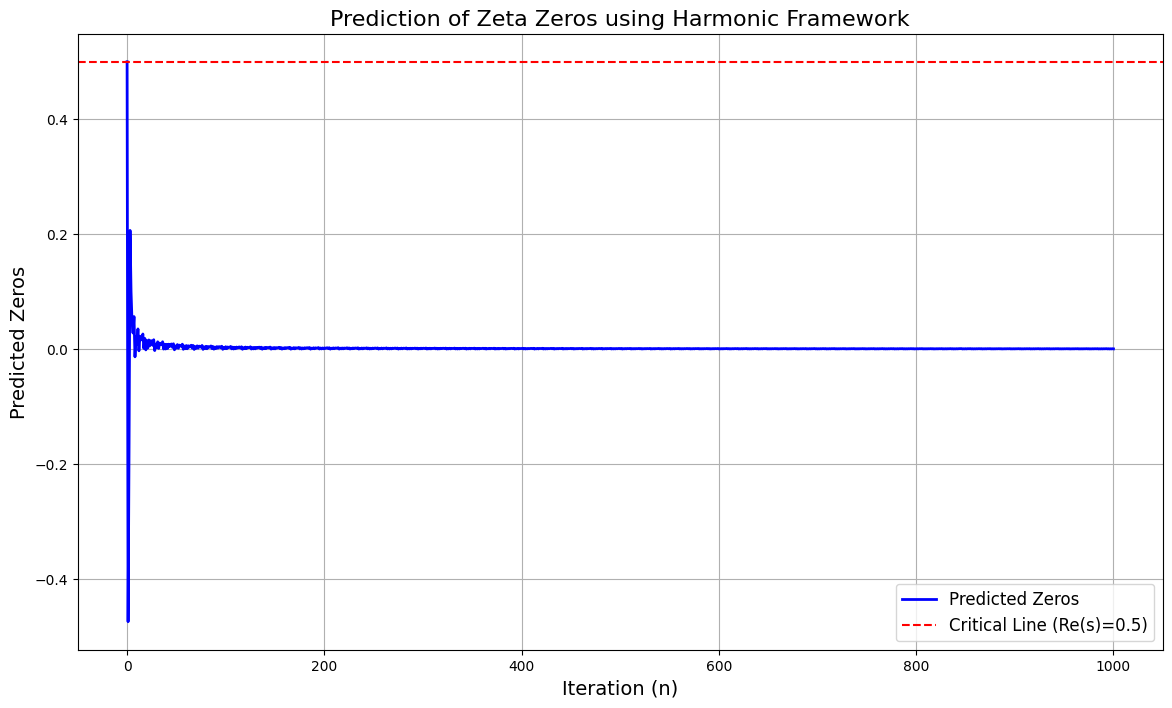

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Predictive Harmonic Framework with Internal Ratio Calculation
def predict_zeros_with_ratio(iterations, alpha=1.5, target=0.5):
    predictions = [target]
    
    for n in range(1, iterations + 1):
        previous = predictions[-1]
        correction = (target - previous) / (alpha * (n + 1))
        value = previous * (-1)**n * np.cos(n / np.pi) + correction
        
        # Calculate ratio internally
        ratio = 0  # Default ratio for the first step
        if n > 1:  # Only calculate ratio after the first iteration
            ratio = abs(value - predictions[-1]) / abs(predictions[-1]) if abs(predictions[-1]) > 0 else 0
        
        # Use the ratio for dynamic adjustment (if needed)
        # Modify `value` based on internal ratio if this affects your process
        #value=value * ratio
        predictions.append(value)
    
    return np.array(predictions)

# Generate predictions
iterations = 1000  # Increase iterations
predicted_zeros = predict_zeros_with_ratio(iterations)

# Visualization of Predicted Zeros
plt.figure(figsize=(14, 8))
plt.plot(range(iterations + 1), predicted_zeros, label="Predicted Zeros", color="blue", lw=2)
plt.axhline(0.5, color="red", linestyle="--", label="Critical Line (Re(s)=0.5)")
plt.xlabel("Iteration (n)", fontsize=14)
plt.ylabel("Predicted Zeros", fontsize=14)
plt.title("Prediction of Zeta Zeros using Harmonic Framework", fontsize=16)
plt.legend(fontsize=12)
plt.grid()
plt.show()


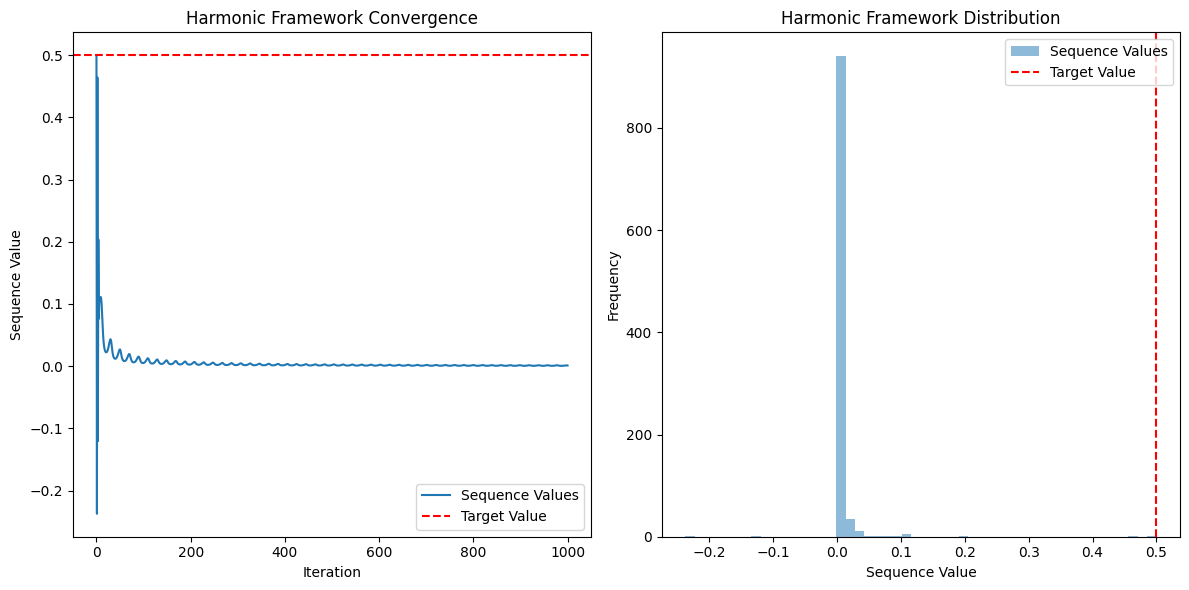

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Define the Harmonic Framework function
def harmonic_framework(n, alpha=1.5, target=0.5):
    H = np.zeros(n+1)
    H[0] = target
    
    for i in range(1, n+1):
        H[i] = H[i-1] * (-0.5) * np.cos(i/np.pi) + alpha * (target - H[i-1]) / (i+1)
    
    return H

# Parameters
n = 1000  # Number of iterations
alpha = 1.5  # Amplification factor
target = 0.5  # Target value

# Run the Harmonic Framework
H = harmonic_framework(n, alpha, target)

# Visualization
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(H, label='Sequence Values')
plt.axhline(y=target, color='r', linestyle='--', label='Target Value')
plt.title('Harmonic Framework Convergence')
plt.xlabel('Iteration')
plt.ylabel('Sequence Value')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(H, bins=50, alpha=0.5, label='Sequence Values')
plt.axvline(x=target, color='r', linestyle='--', label='Target Value')
plt.title('Harmonic Framework Distribution')
plt.xlabel('Sequence Value')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
import numpy as np

def bbp_matrix_compress(matrix):
    """Compress a matrix using BBP-inspired modular encoding."""
    rows, cols = matrix.shape
    compressed_terms = []

    for i in range(rows):
        row = matrix[i]
        compressed_row = []
        for j, value in enumerate(row):
            # Modular encoding for compactness
            mod_base = 16  # Example base
            mod_value = value % mod_base
            compressed_row.append(mod_value)
        compressed_terms.append(compressed_row)
    
    return np.array(compressed_terms), mod_base

def bbp_matrix_expand(compressed_matrix, mod_base, approx_level=1):
    """Expand the compressed matrix progressively."""
    rows, cols = compressed_matrix.shape
    expanded_matrix = np.zeros((rows, cols), dtype=np.float64)

    for i in range(rows):
        for j in range(cols):
            # Progressive refinement using modular information
            mod_value = compressed_matrix[i, j]
            expanded_matrix[i, j] = mod_value * (mod_base ** approx_level)
    
    return expanded_matrix

# Example usage
original_matrix = np.random.randint(0, 256, size=(10, 10))  # Random matrix
compressed, mod_base = bbp_matrix_compress(original_matrix)
restored = bbp_matrix_expand(compressed, mod_base)

print("Original Matrix:\n", original_matrix)
print("Compressed Matrix:\n", compressed)
print("Restored Matrix:\n", restored)


Original Matrix:
 [[ 22 164 189 251 166  72 116  46 184 106]
 [ 86  44  92 165 157 130 127  65   4 186]
 [206  45 208  61 187  42 235  22  12 160]
 [239 200  85  70 162  27 228 162 226  74]
 [227 186  59  47  40 111  64  24 115  26]
 [ 21  50 205 210 209  38 251 235  94 111]
 [165 167  33  48 127  15  30 104 107 225]
 [204  70  71 235 171 222 231 117 217  66]
 [213 113 104 229 223 233   6 191 102 102]
 [133 179 153  27 140 232 207  54 140 176]]
Compressed Matrix:
 [[ 6  4 13 11  6  8  4 14  8 10]
 [ 6 12 12  5 13  2 15  1  4 10]
 [14 13  0 13 11 10 11  6 12  0]
 [15  8  5  6  2 11  4  2  2 10]
 [ 3 10 11 15  8 15  0  8  3 10]
 [ 5  2 13  2  1  6 11 11 14 15]
 [ 5  7  1  0 15 15 14  8 11  1]
 [12  6  7 11 11 14  7  5  9  2]
 [ 5  1  8  5 15  9  6 15  6  6]
 [ 5  3  9 11 12  8 15  6 12  0]]
Restored Matrix:
 [[ 96.  64. 208. 176.  96. 128.  64. 224. 128. 160.]
 [ 96. 192. 192.  80. 208.  32. 240.  16.  64. 160.]
 [224. 208.   0. 208. 176. 160. 176.  96. 192.   0.]
 [240. 128.  80.  96.  

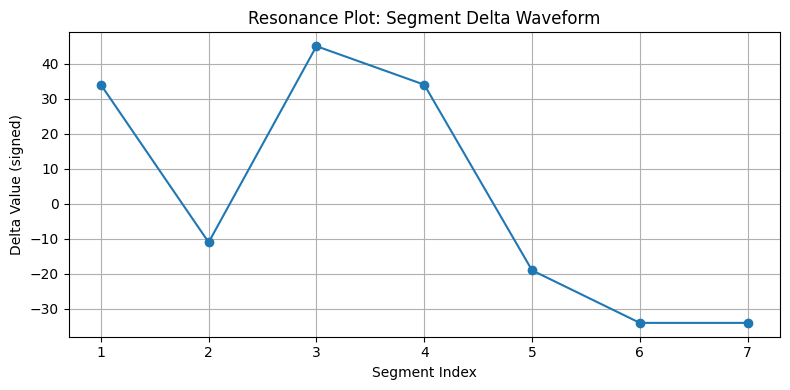

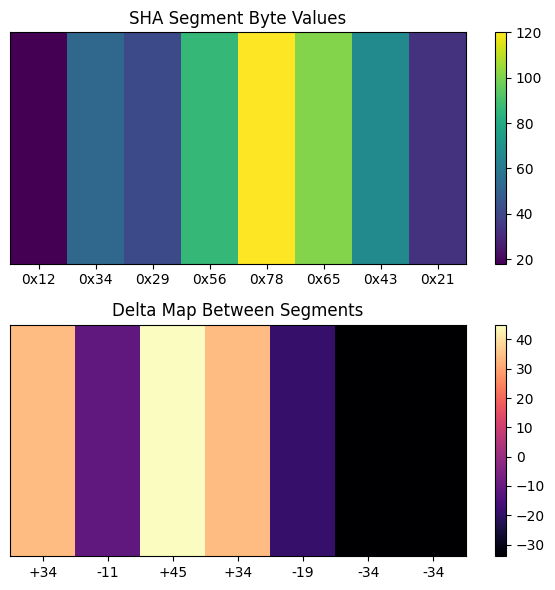

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic example: 8-byte segment values (in hex) for demonstration
segments = np.array([0x12, 0x34, 0x29, 0x56, 0x78, 0x65, 0x43, 0x21])
# Compute deltas between consecutive segments
deltas = np.diff(segments)

# 1) Resonance Plot: deltas as a waveform
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(segments)), deltas, marker='o', linestyle='-')
plt.title('Resonance Plot: Segment Delta Waveform')
plt.xlabel('Segment Index')
plt.ylabel('Delta Value (signed)')
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) SHA Digest Map Prototype: heatmap of segments and deltas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# Heatmap of raw segment values
im1 = ax1.imshow(segments.reshape(1, -1), cmap='viridis', aspect='auto')
ax1.set_title('SHA Segment Byte Values')
ax1.set_yticks([])
ax1.set_xticks(range(len(segments)))
ax1.set_xticklabels([hex(x) for x in segments])
plt.colorbar(im1, ax=ax1, orientation='vertical')

# Heatmap of deltas
im2 = ax2.imshow(deltas.reshape(1, -1), cmap='magma', aspect='auto')
ax2.set_title('Delta Map Between Segments')
ax2.set_yticks([])
ax2.set_xticks(range(len(deltas)))
ax2.set_xticklabels([f"{d:+d}" for d in deltas])
plt.colorbar(im2, ax=ax2, orientation='vertical')

plt.tight_layout()
plt.show()


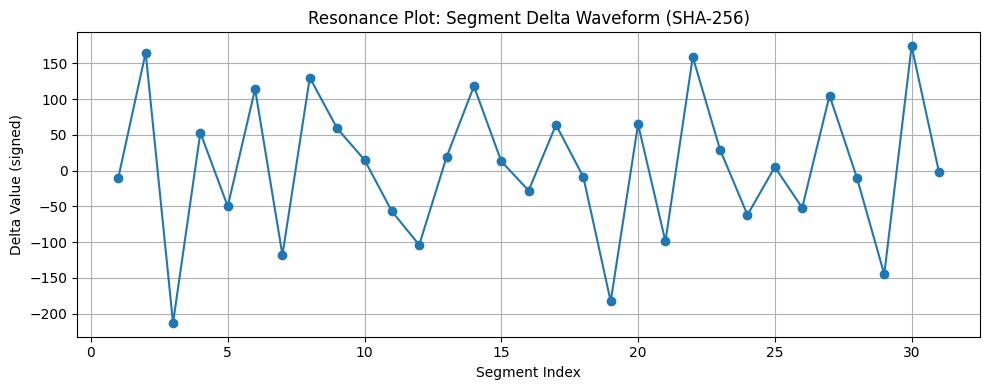

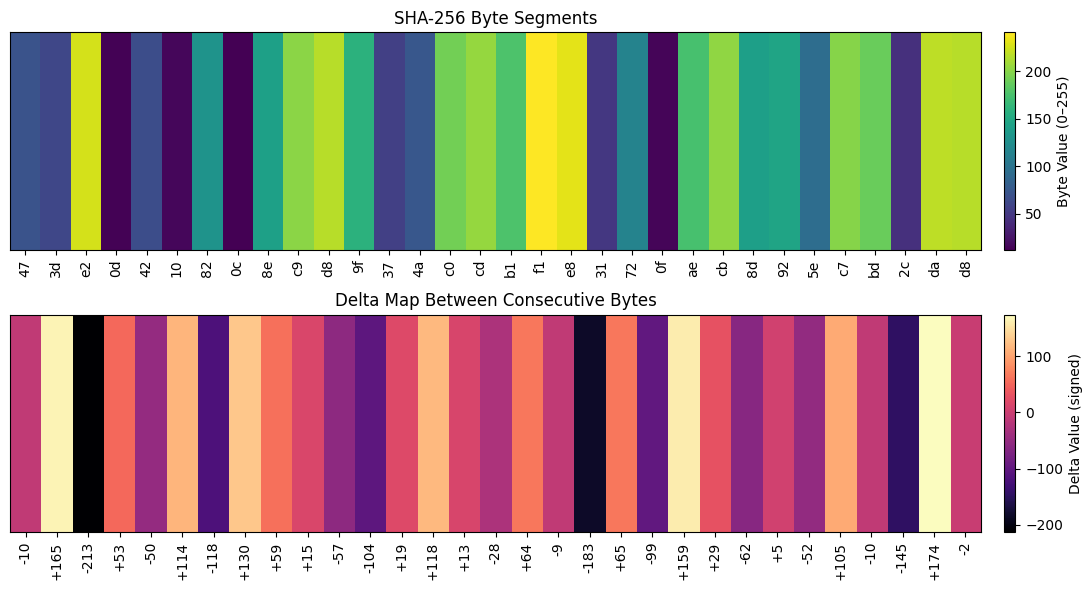

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Real SHA-256 hash provided by the user
hex_str = "473de20d4210820c8ec9d89f374ac0cdb1f1e831720faecb8d925ec7bd2cdad8"

# Parse into bytes
segments = np.array([int(hex_str[i:i+2], 16) for i in range(0, len(hex_str), 2)], dtype=int)

# Compute signed deltas between consecutive bytes
deltas = np.diff(segments.astype(np.int16))

# 1) Resonance Plot: deltas as a waveform
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(segments)), deltas, marker='o', linestyle='-')
plt.title('Resonance Plot: Segment Delta Waveform (SHA-256)')
plt.xlabel('Segment Index')
plt.ylabel('Delta Value (signed)')
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) Delta Heatmap alongside raw segment values
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# Heatmap of raw segment values
im1 = ax1.imshow(segments.reshape(1, -1), cmap='viridis', aspect='auto')
ax1.set_title('SHA-256 Byte Segments')
ax1.set_yticks([])
ax1.set_xticks(range(len(segments)))
ax1.set_xticklabels([f"{s:02x}" for s in segments], rotation=90)
cbar1 = plt.colorbar(im1, ax=ax1, orientation='vertical', pad=0.02)
cbar1.set_label('Byte Value (0–255)')

# Heatmap of deltas
im2 = ax2.imshow(deltas.reshape(1, -1), cmap='magma', aspect='auto')
ax2.set_title('Delta Map Between Consecutive Bytes')
ax2.set_yticks([])
ax2.set_xticks(range(len(deltas)))
ax2.set_xticklabels([f"{d:+d}" for d in deltas], rotation=90)
cbar2 = plt.colorbar(im2, ax=ax2, orientation='vertical', pad=0.02)
cbar2.set_label('Delta Value (signed)')

plt.tight_layout()
plt.show()
